# Unsupervised Movie Recommendation with Nearest Neighbors

## 1. Project Overview

This notebook builds a content-based, unsupervised movie recommendation system. It does not predict ratings and has no target variable. Given a movie, it retrieves nearby movies from an engineered metadata space using `NearestNeighbors`. Configuration is selected with transparent intrinsic metrics: similarity, metadata overlap, diversity, and coverage.

## 2. Imports

In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Any
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import Normalizer, OneHotEncoder, StandardScaler

## 3. Configuration

In [2]:
RANDOM_STATE = 42
FINAL_K = 10
K_VALUES = [5, 10, 15, 20, 25, 50]
DISTANCE_METRICS = ["cosine", "euclidean", "manhattan"]
EVALUATION_CATALOG_SIZE = 15_000
EVALUATION_QUERY_COUNT = 250
MAX_TFIDF_FEATURES = 5_000
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "movies.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_PATH = PROJECT_ROOT / "models" / "final_nearest_neighbors.joblib"
TEXT_FEATURES = ["genres", "keywords", "overview", "tagline"]
CATEGORICAL_FEATURES = ["original_language"]
NUMERIC_FEATURES = ["runtime", "popularity", "vote_average", "vote_count", "release_year"]
RESULTS_DIR.mkdir(exist_ok=True)
MODEL_PATH.parent.mkdir(exist_ok=True)

## 4. Load Dataset

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")
raw_movies = pd.read_csv(DATA_PATH)
ORIGINAL_ROWS = len(raw_movies)
print(f"Original dataset: {ORIGINAL_ROWS:,} rows × {raw_movies.shape[1]} columns")
display(raw_movies.head())

Original dataset: 1,482,601 rows × 24 columns


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## 5. Dataset Diagnostics

In [4]:
required = {"id", "title", "release_date", *TEXT_FEATURES, *CATEGORICAL_FEATURES, *NUMERIC_FEATURES[:-1]}
missing_columns = required.difference(raw_movies.columns)
if missing_columns:
    raise ValueError(f"Required columns missing: {sorted(missing_columns)}")
print(f"Exact duplicate rows: {raw_movies.duplicated().sum():,}")
print(f"Duplicate IDs: {raw_movies['id'].duplicated().sum():,}")
display(raw_movies.dtypes.astype(str).rename("dtype").to_frame())

Exact duplicate rows: 383
Duplicate IDs: 1,341


,dtype
id,int64
title,object
vote_average,float64
vote_count,int64
status,object
release_date,object
revenue,int64
runtime,int64
adult,bool
backdrop_path,object


## 6. Missing Data Analysis

In [5]:
treatments = {
    **{name: "empty string + missing indicator" for name in TEXT_FEATURES},
    "original_language": "'unknown' + missing indicator",
    "runtime": "median + missing indicator",
    "popularity": "median + missing indicator",
    "vote_average": "median + missing indicator",
    "vote_count": "median + missing indicator",
    "release_year": "median + missing indicator",
}
diagnostic_frame = raw_movies.copy()
diagnostic_frame["release_year"] = pd.to_datetime(diagnostic_frame["release_date"], errors="coerce").dt.year
missing_data_report = pd.DataFrame({
    "Feature": list(treatments),
    "Missing Count": [diagnostic_frame[name].isna().sum() for name in treatments],
    "Missing Percentage": [diagnostic_frame[name].isna().mean() * 100 for name in treatments],
    "Chosen Treatment": list(treatments.values()),
})
missing_data_report.to_csv(RESULTS_DIR / "missing_data_report.csv", index=False)
display(missing_data_report)
del diagnostic_frame

,Feature,Missing Count,Missing Percentage,Chosen Treatment
0,genres,662523,44.686534,empty string + missing indicator
1,keywords,1121634,75.653126,empty string + missing indicator
2,overview,344299,23.222634,empty string + missing indicator
3,tagline,1275053,86.001089,empty string + missing indicator
4,original_language,0,0.000000,'unknown' + missing indicator
5,runtime,0,0.000000,median + missing indicator
6,popularity,0,0.000000,median + missing indicator
7,vote_average,0,0.000000,median + missing indicator
8,vote_count,0,0.000000,median + missing indicator
9,release_year,346135,23.346470,median + missing indicator


## 7. Data Retention Analysis

In [6]:
retention_rows = []
def record_retention(stage: str, rows: int) -> None:
    retention_rows.append({
        "Stage": stage,
        "Rows Remaining": rows,
        "Rows Removed": ORIGINAL_ROWS - rows,
        "Percentage Retained": rows / ORIGINAL_ROWS * 100,
    })
record_retention("Original Dataset", len(raw_movies))

## 8. Data Cleaning

In [7]:
movies = raw_movies.copy()
movies["title"] = movies["title"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
movies = movies.loc[movies["title"].ne("") & movies["id"].notna()].copy()
record_retention("After Required Identifier/Title Check", len(movies))

movies["release_year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year
movies = movies.sort_values(["vote_count", "popularity"], ascending=False, na_position="last")
movies = movies.drop_duplicates(subset=["id"], keep="first")
# Same title/year is an obvious duplicate only when a year is known. Unknown-year
# titles are retained because they may be legitimate remakes or unrelated movies.
known_year = movies["release_year"].notna()
movies_with_year = movies.loc[known_year].drop_duplicates(subset=["title", "release_year"], keep="first")
movies_without_year = movies.loc[~known_year]
movies = pd.concat([movies_with_year, movies_without_year]).sort_index()
record_retention("After Duplicate Removal", len(movies))

for feature in TEXT_FEATURES:
    movies[f"{feature}_missing"] = movies[feature].isna().astype("int8")
    movies[feature] = movies[feature].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
movies["original_language_missing"] = movies["original_language"].isna().astype("int8")
movies["original_language"] = movies["original_language"].fillna("unknown").astype(str).replace("", "unknown")
for feature in NUMERIC_FEATURES:
    movies[f"{feature}_missing"] = movies[feature].isna().astype("int8")
    movies[feature] = pd.to_numeric(movies[feature], errors="coerce")
    movies[feature] = movies[feature].fillna(movies[feature].median())
record_retention("After Feature-wise Missing-value Treatment", len(movies))
movies = movies.sort_index().reset_index(drop=True)
record_retention("Final Recommendation Catalog", len(movies))

data_retention_report = pd.DataFrame(retention_rows)
data_retention_report.to_csv(RESULTS_DIR / "data_retention_report.csv", index=False)
display(data_retention_report)

,Stage,Rows Remaining,Rows Removed,Percentage Retained
0,Original Dataset,1482601,0,100.000000
1,After Required Identifier/Title Check,1482578,23,99.998449
2,After Duplicate Removal,1458577,24024,98.379604
3,After Feature-wise Missing-value Treatment,1458577,24024,98.379604
4,Final Recommendation Catalog,1458577,24024,98.379604


## 9. Feature Engineering

In [8]:
def token_set(value: Any) -> set[str]:
    return {part.strip().casefold() for part in str(value).split(",") if part.strip()}

MISSING_INDICATORS = [f"{name}_missing" for name in [*TEXT_FEATURES, "original_language", *NUMERIC_FEATURES]]
evaluation_movies = movies.sample(min(EVALUATION_CATALOG_SIZE, len(movies)), random_state=RANDOM_STATE).reset_index(drop=True)
evaluation_query_indices = np.random.default_rng(RANDOM_STATE).choice(
    len(evaluation_movies), min(EVALUATION_QUERY_COUNT, len(evaluation_movies)), replace=False
)
print(f"Experiment catalog: {len(evaluation_movies):,}; evaluation queries: {len(evaluation_query_indices):,}")

Experiment catalog: 15,000; evaluation queries: 250


## 10. TF-IDF / Encoding

In [9]:
def fit_feature_matrix(frame, text_features, numeric_features=(), include_language=False,
                       text_weights=None, representation="separate", max_features=MAX_TFIDF_FEATURES):
    text_weights = text_weights or {name: 1.0 for name in text_features}
    blocks, transformers = [], {"representation": representation, "text": {}}
    if representation == "combined":
        combined = frame[list(text_features)].fillna("").astype(str).agg(" ".join, axis=1)
        vectorizer = TfidfVectorizer(stop_words="english", max_features=max_features, min_df=2, ngram_range=(1, 2))
        blocks.append(vectorizer.fit_transform(combined))
        transformers["text"]["combined"] = vectorizer
    else:
        per_feature_limit = max(250, max_features // max(1, len(text_features)))
        for feature in text_features:
            vectorizer = TfidfVectorizer(stop_words="english", max_features=per_feature_limit, min_df=2, ngram_range=(1, 2))
            block = vectorizer.fit_transform(frame[feature]) * float(text_weights.get(feature, 1.0))
            blocks.append(block)
            transformers["text"][feature] = vectorizer
    if numeric_features:
        scaler = StandardScaler()
        numeric = scaler.fit_transform(np.log1p(frame[list(numeric_features)].clip(lower=0)))
        numeric_weight = float(text_weights.get("numeric", 1.0))
        blocks.append(csr_matrix(numeric * numeric_weight))
        transformers["numeric_scaler"] = scaler
        transformers["numeric_features"] = list(numeric_features)
    if include_language:
        encoder = OneHotEncoder(handle_unknown="ignore")
        blocks.append(encoder.fit_transform(frame[["original_language"]]) * float(text_weights.get("language", 1.0)))
        transformers["language_encoder"] = encoder
    indicator_names = [name for name in MISSING_INDICATORS if name in frame]
    if indicator_names:
        blocks.append(csr_matrix(frame[indicator_names].to_numpy(dtype="float32") * 0.1))
        transformers["indicators"] = indicator_names
    matrix = hstack(blocks, format="csr", dtype="float32")
    return matrix, transformers

## 11. Feature Matrix Construction

In [10]:
BASE_FEATURES = ["genres", "keywords", "overview", "tagline"]
baseline_matrix, baseline_transformers = fit_feature_matrix(
    evaluation_movies, BASE_FEATURES, representation="combined"
)
print(f"Baseline matrix: {baseline_matrix.shape}; non-zero values: {baseline_matrix.nnz:,}")

Baseline matrix: (15000, 5010); non-zero values: 264,608


## 12. NearestNeighbors Baseline

In [11]:
baseline_model = NearestNeighbors(n_neighbors=FINAL_K + 1, metric="cosine", algorithm="brute", n_jobs=-1)
baseline_model.fit(baseline_matrix)
distances, indices = baseline_model.kneighbors(baseline_matrix[evaluation_query_indices])
print("Baseline index fitted without a target: model.fit(X)")

Baseline index fitted without a target: model.fit(X)


## 13. K Experiments

,K,Average Similarity,Genre Overlap@K,Keyword Overlap@K,Diversity@K,Catalog Coverage,Recommendation Coverage,Mean Distance,Median Distance,Distance Std
0,5,0.462069,0.259013,0.041160,0.517419,0.062400,1.0,0.537930,0.675425,0.291669
1,10,0.435517,0.249825,0.034868,0.546681,0.112733,1.0,0.564483,0.702738,0.297565
2,15,0.419449,0.245719,0.032536,0.551003,0.154467,1.0,0.580551,0.721786,0.300991
3,20,0.408058,0.244685,0.030597,0.557527,0.193533,1.0,0.591942,0.736513,0.303319
4,25,0.399319,0.246444,0.027423,0.565462,0.231733,1.0,0.600681,0.748005,0.305194
5,50,0.372532,0.245432,0.021749,0.560830,0.400467,1.0,0.627468,0.783925,0.311069


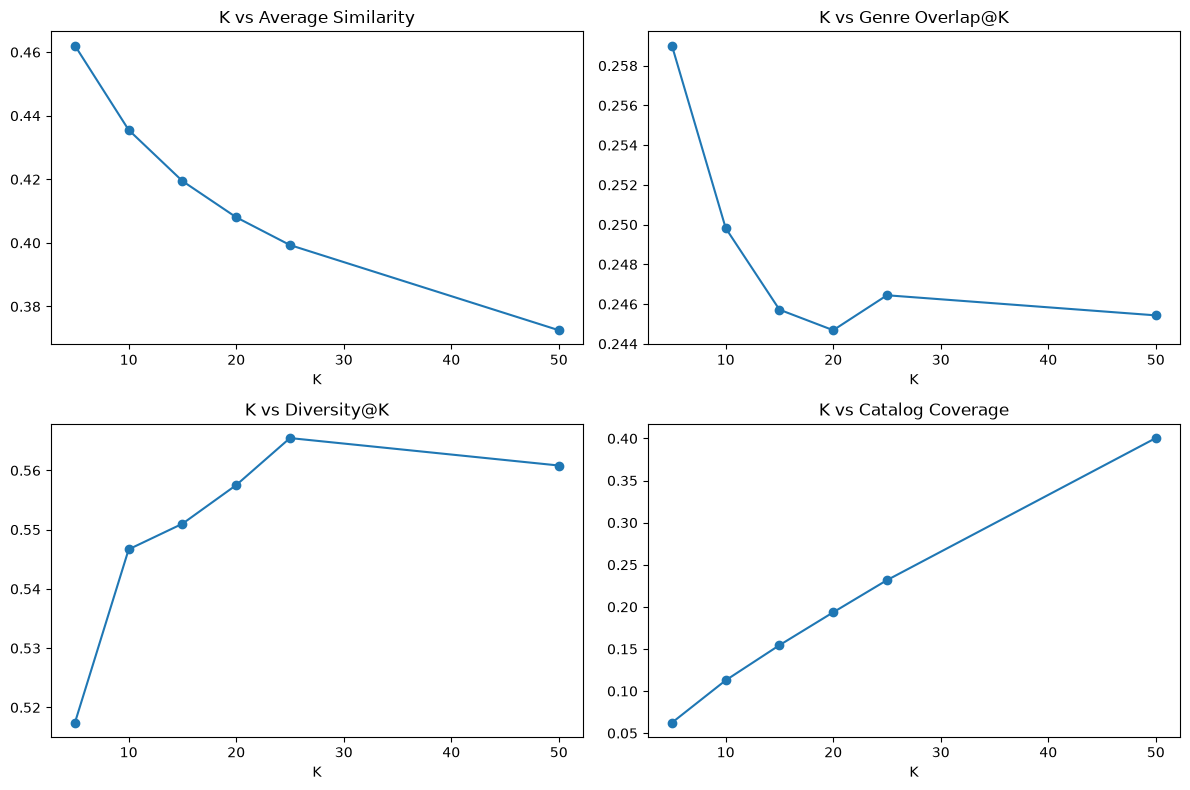

In [12]:
def jaccard(left, right):
    union = left | right
    return len(left & right) / len(union) if union else 0.0

def evaluate_neighbors(frame, matrix, metric="cosine", k=10, query_indices=evaluation_query_indices):
    model = NearestNeighbors(n_neighbors=min(k + 1, len(frame)), metric=metric, algorithm="brute", n_jobs=-1).fit(matrix)
    raw_distances, raw_indices = model.kneighbors(matrix[query_indices])
    recommendation_rows, cosine_scores, genre_scores, keyword_scores, diversities = [], [], [], [], []
    successful = 0
    for query_position, query_index in enumerate(query_indices):
        pairs = [(idx, dist) for idx, dist in zip(raw_indices[query_position], raw_distances[query_position]) if idx != query_index][:k]
        if len(pairs) == k:
            successful += 1
        rec_indices = [idx for idx, _ in pairs]
        recommendation_rows.extend(rec_indices)
        if not rec_indices:
            continue
        similarities = cosine_similarity(matrix[query_index:query_index + 1], matrix[rec_indices]).ravel()
        cosine_scores.extend(similarities.tolist())
        query_genres, query_keywords = token_set(frame.iloc[query_index]["genres"]), token_set(frame.iloc[query_index]["keywords"])
        genre_scores.extend(jaccard(query_genres, token_set(frame.iloc[idx]["genres"])) for idx in rec_indices)
        keyword_scores.extend(jaccard(query_keywords, token_set(frame.iloc[idx]["keywords"])) for idx in rec_indices)
        if len(rec_indices) > 1:
            pairwise = cosine_similarity(matrix[rec_indices])
            upper = pairwise[np.triu_indices_from(pairwise, k=1)]
            diversities.append(float(1 - upper.mean()))
    nearest_distances = raw_distances[:, 1:].ravel() if raw_distances.shape[1] > 1 else np.array([])
    return {
        "Average Similarity": float(np.mean(cosine_scores)),
        "Genre Overlap@K": float(np.mean(genre_scores)),
        "Keyword Overlap@K": float(np.mean(keyword_scores)),
        "Diversity@K": float(np.mean(diversities)),
        "Catalog Coverage": len(set(recommendation_rows)) / len(frame),
        "Recommendation Coverage": successful / len(query_indices),
        "Mean Distance": float(np.mean(nearest_distances)),
        "Median Distance": float(np.median(nearest_distances)),
        "Distance Std": float(np.std(nearest_distances)),
    }

k_rows = []
for k in K_VALUES:
    k_rows.append({"K": k, **evaluate_neighbors(evaluation_movies, baseline_matrix, "cosine", k)})
k_results = pd.DataFrame(k_rows)
display(k_results)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric in zip(axes.ravel(), ["Average Similarity", "Genre Overlap@K", "Diversity@K", "Catalog Coverage"]):
    k_results.plot(x="K", y=metric, marker="o", ax=ax, legend=False, title=f"K vs {metric}")
plt.tight_layout(); plt.show()

## 14. Distance Metric Experiments

In [13]:
distance_results = pd.DataFrame([
    {"Distance Metric": metric, **evaluate_neighbors(evaluation_movies, baseline_matrix, metric, FINAL_K)}
    for metric in DISTANCE_METRICS
])
display(distance_results)

,Distance Metric,Average Similarity,Genre Overlap@K,Keyword Overlap@K,Diversity@K,Catalog Coverage,Recommendation Coverage,Mean Distance,Median Distance,Distance Std
0,cosine,0.435517,0.249825,0.034868,0.546681,0.112733,1.0,0.564483,0.702738,0.297565
1,euclidean,0.320649,0.085500,0.011267,0.086542,0.019467,1.0,0.802332,1.000000,0.393126
2,manhattan,0.318549,0.090267,0.011267,0.075803,0.017133,1.0,3.195336,3.650461,1.931442


## 15. Feature Ablation Study

In [14]:
ABLATIONS = [
    ("E1", ["genres"], [], False), ("E2", ["keywords"], [], False),
    ("E3", ["overview"], [], False), ("E4", ["genres", "keywords"], [], False),
    ("E5", ["genres", "overview"], [], False), ("E6", ["keywords", "overview"], [], False),
    ("E7", ["genres", "keywords", "overview"], [], False),
    ("E8", TEXT_FEATURES, [], False),
    ("E9", ["genres", "keywords", "overview"], [], True),
    ("E10", ["genres", "keywords", "overview"], ["runtime"], False),
    ("E11", ["genres", "keywords", "overview"], ["popularity"], False),
    ("E12", TEXT_FEATURES, NUMERIC_FEATURES, True),
]
experiment_rows = []
for experiment, text_features, numeric_features, language in ABLATIONS:
    matrix, _ = fit_feature_matrix(evaluation_movies, text_features, numeric_features, language, representation="separate")
    metrics = evaluate_neighbors(evaluation_movies, matrix, "cosine", FINAL_K)
    experiment_rows.append({
        "Experiment": experiment,
        "Features": ", ".join(text_features + numeric_features + (["original_language"] if language else [])),
        "Rows Used": len(evaluation_movies), "Dataset Percentage Used": len(evaluation_movies) / len(movies) * 100,
        "Vector Dimensions": matrix.shape[1], "Distance Metric": "cosine", "K": FINAL_K, **metrics,
    })
experiment_results = pd.DataFrame(experiment_rows)
display(experiment_results)

,Experiment,Features,Rows Used,Dataset Percentage Used,Vector Dimensions,Distance Metric,K,Average Similarity,Genre Overlap@K,Keyword Overlap@K,Diversity@K,Catalog Coverage,Recommendation Coverage,Mean Distance,Median Distance,Distance Std
0,E1,genres,15000,1.0284,276,cosine,10,0.981325,0.469794,0.006594,0.023424,0.055333,1.0,0.018675,0.000000e+00,0.074855
1,E2,keywords,15000,1.0284,2967,cosine,10,0.907251,0.094253,0.078177,0.097957,0.040000,1.0,0.092749,5.960464e-08,0.227021
2,E3,overview,15000,1.0284,5010,cosine,10,0.427972,0.069498,0.003831,0.617078,0.110200,1.0,0.572028,7.342637e-01,0.318377
3,E4,"genres, keywords",15000,1.0284,2776,cosine,10,0.917767,0.462840,0.057379,0.070010,0.063533,1.0,0.082233,5.960464e-08,0.173530
4,E5,"genres, overview",15000,1.0284,2776,cosine,10,0.587951,0.462640,0.005513,0.358998,0.102400,1.0,0.412049,2.998600e-01,0.278049
5,E6,"keywords, overview",15000,1.0284,5010,cosine,10,0.465680,0.089100,0.072718,0.591351,0.115133,1.0,0.534320,6.745242e-01,0.298599
6,E7,"genres, keywords, overview",15000,1.0284,3608,cosine,10,0.580462,0.454667,0.051362,0.375017,0.102600,1.0,0.419538,4.263862e-01,0.265243
7,E8,"genres, keywords, overview, tagline",15000,1.0284,4026,cosine,10,0.579318,0.450893,0.050628,0.376176,0.101333,1.0,0.420682,4.263862e-01,0.262169
8,E9,"genres, keywords, overview, original_language",15000,1.0284,3703,cosine,10,0.742697,0.371800,0.033440,0.112165,0.084000,1.0,0.257303,2.876875e-01,0.144323
9,E10,"genres, keywords, overview, runtime",15000,1.0284,3609,cosine,10,0.720970,0.425720,0.040380,0.151157,0.079933,1.0,0.279030,2.559618e-01,0.196476


## 16. Feature Weight Experiments

In [15]:
WEIGHT_CONFIGURATIONS = {
    "equal": {"genres": 1, "keywords": 1, "overview": 1, "tagline": 1, "numeric": 1, "language": 1},
    "metadata_emphasis": {"genres": 3, "keywords": 3, "overview": 1.5, "tagline": 0.5, "numeric": 0.25, "language": 0.5},
    "narrative_emphasis": {"genres": 1.5, "keywords": 2, "overview": 3, "tagline": 1, "numeric": 0.25, "language": 0.25},
    "balanced": {"genres": 2, "keywords": 2, "overview": 1.5, "tagline": 0.75, "numeric": 0.5, "language": 0.5},
}
weight_rows, weighted_matrices = [], {}
for name, weights in WEIGHT_CONFIGURATIONS.items():
    matrix, transformers = fit_feature_matrix(
        evaluation_movies, TEXT_FEATURES, NUMERIC_FEATURES, True,
        text_weights=weights, representation="separate"
    )
    weighted_matrices[name] = (matrix, transformers)
    weight_rows.append({"Weight Configuration": name, **evaluate_neighbors(evaluation_movies, matrix, "cosine", FINAL_K)})
weight_results = pd.DataFrame(weight_rows)
display(weight_results)

,Weight Configuration,Average Similarity,Genre Overlap@K,Keyword Overlap@K,Diversity@K,Catalog Coverage,Recommendation Coverage,Mean Distance,Median Distance,Distance Std
0,equal,0.820830,0.274058,0.019483,0.126541,0.107600,1.0,0.179170,0.172829,0.107563
1,metadata_emphasis,0.680474,0.464361,0.057415,0.219327,0.111600,1.0,0.319526,0.305055,0.240617
2,narrative_emphasis,0.497612,0.369316,0.050493,0.465576,0.128267,1.0,0.502388,0.575261,0.253693
3,balanced,0.661094,0.453248,0.050022,0.223734,0.107133,1.0,0.338906,0.364986,0.192366


## 17. Dimensionality Reduction Experiments

In [16]:
preliminary_weight_scores = weight_results.assign(
    _score=(weight_results["Average Similarity"] * 0.35
            + weight_results["Genre Overlap@K"] * 0.20
            + weight_results["Keyword Overlap@K"] * 0.20
            + weight_results["Diversity@K"] * 0.15
            + weight_results["Catalog Coverage"] * 0.10)
)
selected_weight_name = preliminary_weight_scores.sort_values("_score", ascending=False).iloc[0]["Weight Configuration"]
selected_matrix = weighted_matrices[selected_weight_name][0]
svd_matrices = {0: selected_matrix}
svd_rows = [{"Representation": "Direct TF-IDF", "SVD Components": 0,
             "Vector Dimensions": selected_matrix.shape[1],
             **evaluate_neighbors(evaluation_movies, selected_matrix, "cosine", FINAL_K)}]
for components in [100, 200, 300, 500, 750, 1000]:
    if components >= min(selected_matrix.shape):
        continue
    reducer = TruncatedSVD(n_components=components, random_state=RANDOM_STATE)
    reduced = Normalizer(copy=False).fit_transform(reducer.fit_transform(selected_matrix)).astype("float32")
    svd_matrices[components] = reduced
    svd_rows.append({"Representation": "TF-IDF + TruncatedSVD", "SVD Components": components,
                     "Vector Dimensions": reduced.shape[1],
                     **evaluate_neighbors(evaluation_movies, reduced, "cosine", FINAL_K)})
svd_results = pd.DataFrame(svd_rows)
display(svd_results)

,Representation,SVD Components,Vector Dimensions,Average Similarity,Genre Overlap@K,Keyword Overlap@K,Diversity@K,Catalog Coverage,Recommendation Coverage,Mean Distance,Median Distance,Distance Std
0,Direct TF-IDF,0,4126,0.680474,0.464361,0.057415,0.219327,0.111600,1.0,0.319526,0.305055,0.240617
1,TF-IDF + TruncatedSVD,100,100,0.955332,0.467567,0.050530,0.047000,0.146533,1.0,0.044668,0.018748,0.068492
2,TF-IDF + TruncatedSVD,200,200,0.911469,0.465920,0.053904,0.094684,0.143400,1.0,0.088531,0.050516,0.101156
3,TF-IDF + TruncatedSVD,300,300,0.875556,0.465661,0.056238,0.128185,0.139867,1.0,0.124444,0.079552,0.125345
4,TF-IDF + TruncatedSVD,500,500,0.821788,0.465161,0.058038,0.167693,0.132533,1.0,0.178212,0.122271,0.157538
5,TF-IDF + TruncatedSVD,750,750,0.777147,0.464481,0.058558,0.189731,0.125667,1.0,0.222853,0.171189,0.184238
6,TF-IDF + TruncatedSVD,1000,1000,0.746976,0.464334,0.058757,0.205185,0.120533,1.0,0.253024,0.229678,0.201806


## 18. Recommendation Evaluation

In [17]:
# Transparent composite: all terms are already in [0, 1]. Individual metrics remain visible.
COMPOSITE_WEIGHTS = {"Average Similarity": 0.35, "Genre Overlap@K": 0.20,
                     "Keyword Overlap@K": 0.20, "Diversity@K": 0.15, "Catalog Coverage": 0.10}
def add_composite(frame):
    result = frame.copy()
    result["Composite Quality"] = sum(result[name] * weight for name, weight in COMPOSITE_WEIGHTS.items())
    return result
weight_results = add_composite(weight_results)
distance_results = add_composite(distance_results)
svd_results = add_composite(svd_results)
experiment_results = add_composite(experiment_results)
experiment_results.to_csv(RESULTS_DIR / "nearest_neighbor_experiments.csv", index=False)
k_results.to_csv(RESULTS_DIR / "k_experiments.csv", index=False)
distance_results.to_csv(RESULTS_DIR / "distance_metric_experiments.csv", index=False)
weight_results.to_csv(RESULTS_DIR / "feature_weight_experiments.csv", index=False)
svd_results.to_csv(RESULTS_DIR / "svd_experiments.csv", index=False)
print("Composite formula:", " + ".join(f"{weight:.2f}×{name}" for name, weight in COMPOSITE_WEIGHTS.items()))

Composite formula: 0.35×Average Similarity + 0.20×Genre Overlap@K + 0.20×Keyword Overlap@K + 0.15×Diversity@K + 0.10×Catalog Coverage


## 19. Final Configuration Selection

In [18]:
# E12 is selected for balanced feature usefulness and catalog robustness. A genre-only
# model can win a genre-overlap-heavy composite tautologically, so raw composite rank
# is not used as the sole feature-selection rule.
best_ablation = experiment_results.loc[experiment_results["Experiment"].eq("E12")].iloc[0]
best_weight = weight_results.sort_values("Composite Quality", ascending=False).iloc[0]
best_distance = distance_results.sort_values("Composite Quality", ascending=False).iloc[0]
best_representation = svd_results.sort_values("Composite Quality", ascending=False).iloc[0]
# K=10 is retained as a practical balance: K=5 is more locally similar, while larger K increases breadth.
SELECTED_K = FINAL_K
SELECTED_WEIGHTS = WEIGHT_CONFIGURATIONS[best_weight["Weight Configuration"]]
SELECTED_METRIC = str(best_distance["Distance Metric"])
SELECTED_SVD = int(best_representation["SVD Components"])
print("Selected weight configuration:", best_weight["Weight Configuration"])
print("Selected distance metric:", SELECTED_METRIC)
print("Selected representation:", best_representation["Representation"], "components:", SELECTED_SVD)
print("Selected K:", SELECTED_K)

Selected weight configuration: metadata_emphasis
Selected distance metric: cosine
Selected representation: TF-IDF + TruncatedSVD components: 100
Selected K: 10


## 20. Final Model

In [19]:
final_matrix, final_transformers = fit_feature_matrix(
    movies, TEXT_FEATURES, NUMERIC_FEATURES, True,
    text_weights=SELECTED_WEIGHTS, representation="separate"
)
final_reducer = None
if SELECTED_SVD:
    final_reducer = TruncatedSVD(n_components=SELECTED_SVD, random_state=RANDOM_STATE)
    final_matrix = Normalizer(copy=False).fit_transform(final_reducer.fit_transform(final_matrix)).astype("float32")
final_model = NearestNeighbors(
    n_neighbors=SELECTED_K + 1, metric=SELECTED_METRIC, algorithm="brute", n_jobs=-1
).fit(final_matrix)
record_retention("Final Recommendation Matrix", final_matrix.shape[0])
data_retention_report = pd.DataFrame(retention_rows).drop_duplicates("Stage", keep="last")
data_retention_report.to_csv(RESULTS_DIR / "data_retention_report.csv", index=False)
print(f"Final matrix: {final_matrix.shape}; retained {len(movies) / ORIGINAL_ROWS:.2%} of original rows")

Final matrix: (1458577, 100); retained 98.38% of original rows


## 21. Recommendation Function

In [20]:
def recommend_movies(movie_title: str, k: int = 10) -> pd.DataFrame:
    matches = movies.index[movies["title"].str.casefold().eq(movie_title.strip().casefold())].tolist()
    if not matches:
        suggestions = movies.loc[movies["title"].str.contains(movie_title, case=False, regex=False), "title"].head(10).tolist()
        raise ValueError(f"Movie not found. Possible matches: {suggestions}")
    query_index = matches[0]
    requested = min(k + len(matches) + 5, len(movies))
    distances, indices = final_model.kneighbors(final_matrix[query_index:query_index + 1], n_neighbors=requested)
    rows, seen = [], {(movies.iloc[query_index]["title"].casefold(), movies.iloc[query_index]["release_year"])}
    for index, distance in zip(indices[0], distances[0]):
        if index == query_index:
            continue
        movie = movies.iloc[index]
        identity = (movie["title"].casefold(), movie["release_year"])
        if identity in seen:
            continue
        seen.add(identity)
        similarity = float(cosine_similarity(final_matrix[query_index:query_index + 1], final_matrix[index:index + 1])[0, 0])
        rows.append({"Rank": len(rows) + 1, "Title": movie["title"], "Similarity": np.clip(similarity, 0, 1),
                     "Genres": movie["genres"], "Release Year": int(movie["release_year"])})
        if len(rows) == k:
            break
    return pd.DataFrame(rows)

## 22. Example Recommendations

In [21]:
example_title = "Interstellar" if movies["title"].str.casefold().eq("interstellar").any() else movies.iloc[0]["title"]
example_recommendations = recommend_movies(example_title, k=10)
print(f"Recommendations for: {example_title}")
display(example_recommendations)

Recommendations for: Interstellar


,Rank,Title,Similarity,Genres,Release Year
0,1,Finch,0.976138,"Science Fiction, Drama, Adventure",2021
1,2,A.I. Artificial Intelligence,0.975822,"Drama, Science Fiction, Adventure",2001
2,3,Midnight Special,0.973196,"Adventure, Drama, Science Fiction",2016
3,4,The Adam Project,0.970188,"Adventure, Science Fiction",2022
4,5,Free Guy,0.963584,"Comedy, Adventure, Science Fiction",2021
5,6,Vesper,0.963418,"Science Fiction, Drama, Adventure",2022
6,7,Jurassic Park,0.959997,"Adventure, Science Fiction",1993
7,8,Avengers: Endgame,0.958221,"Adventure, Science Fiction, Action",2019
8,9,Prometheus,0.955532,"Science Fiction, Adventure, Mystery",2012
9,10,Jurassic World Dominion,0.955326,"Adventure, Action, Science Fiction",2022


## 23. Final Results Summary

In [22]:
final_evaluation = evaluate_neighbors(
    evaluation_movies, svd_matrices[SELECTED_SVD], SELECTED_METRIC, SELECTED_K
)
artifact = {
    "model": final_model, "feature_matrix": final_matrix, "transformers": final_transformers,
    "svd": final_reducer, "catalog": movies[["id", "title", "genres", "release_year"]],
    "configuration": {"k": SELECTED_K, "metric": SELECTED_METRIC,
                      "weights": SELECTED_WEIGHTS, "svd_components": SELECTED_SVD},
}
joblib.dump(artifact, MODEL_PATH, compress=3)
summary = pd.Series({
    "Original Dataset Size": ORIGINAL_ROWS, "Final Usable Dataset Size": len(movies),
    "Dataset Retained (%)": len(movies) / ORIGINAL_ROWS * 100, "Rows Removed": ORIGINAL_ROWS - len(movies),
    "Main Reasons for Removal": "missing identifier/title; duplicate ID or same title/year",
    "Best Feature Combination": best_ablation["Features"],
    "Best Feature Weights": json.dumps(SELECTED_WEIGHTS),
    "Best Representation": best_representation["Representation"],
    "Best Distance Metric": SELECTED_METRIC, "Selected K": SELECTED_K,
    **final_evaluation, "Dimensionality": final_matrix.shape[1], "SVD Components": SELECTED_SVD,
    "Final Recommendation Example": example_title,
})
display(summary.rename("Final Result"))
print("This is an unsupervised nearest-neighbor recommendation system. It does not predict whether a user will like a movie. It finds movies that are close in engineered feature space, so quality is evaluated with intrinsic recommendation metrics—not supervised accuracy. User interactions could later support a hybrid system.")

Original Dataset Size                                                     1482601
Final Usable Dataset Size                                                 1458577
Dataset Retained (%)                                                    98.379604
Rows Removed                                                                24024
Main Reasons for Removal        missing identifier/title; duplicate ID or same...
Best Feature Combination        genres, keywords, overview, tagline, runtime, ...
Best Feature Weights            {"genres": 3, "keywords": 3, "overview": 1.5, ...
Best Representation                                         TF-IDF + TruncatedSVD
Best Distance Metric                                                       cosine
Selected K                                                                     10
Average Similarity                                                       0.955332
Genre Overlap@K                                                          0.467567
Keyword Overlap@

This is an unsupervised nearest-neighbor recommendation system. It does not predict whether a user will like a movie. It finds movies that are close in engineered feature space, so quality is evaluated with intrinsic recommendation metrics—not supervised accuracy. User interactions could later support a hybrid system.
